
# Predicción de Series Temporales con MLP

## Objetivo
Aplicar un **Multilayer Perceptron (MLP)** para predecir valores futuros de una serie temporal de tipo de cambio.

El dataset contiene el tipo de cambio entre el dólar estadounidense (USD) y varias monedas, incluyendo el **Yuan chino (CNY)**.

---

## Conceptos importantes

### Serie temporal
Una serie temporal es una secuencia de datos ordenados en el tiempo.

Ejemplo:
```
Día 1 → precio
Día 2 → precio
Día 3 → precio
```

El objetivo es **predecir el valor futuro usando valores pasados**.

---

### Multilayer Perceptron (MLP)
Un MLP es una red neuronal feedforward compuesta por:

- Capa de entrada
- Capas ocultas
- Capa de salida

En este trabajo se usa para aproximar la relación entre valores históricos del tipo de cambio y su valor futuro.

---

### Por qué usar MLP en esta práctica
Aunque existen modelos diseñados para secuencias (como RNN o LSTM), el objetivo es:

- transformar una serie temporal en un problema supervisado
- entrenar un modelo de red neuronal básica

---



## Paso 1 — Importar librerías
Las librerías utilizadas permiten:

- manipulación de datos
- entrenamiento del modelo
- visualización de resultados


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



## Paso 2 — Cargar el dataset

El dataset contiene:
- fecha
- precios de apertura
- precios máximos
- precios mínimos
- precio de cierre
- variaciones porcentuales

En este proyecto se utilizará el **tipo de cambio USD/CNY**.


In [112]:

df = pd.read_csv("archive/Usd-PKRINRCNY.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.head()


,Date,Open_pkr,High_pkr,Low_pkr,Close_pkr,Adj Close_pkr,Open_inr,High_inr,Low_inr,Close_inr,Adj Close_inr,Open,High,Low,Close,Adj Close,PKR_pct_change,INR_pct_change,CNY_pct_change
0,2004-01-05,55.42,55.42,55.42,57.10,57.10,45.53,45.56,45.46,45.47,45.47,8.27,8.27,8.27,8.27,8.27,0.00,-0.30,0.0
1,2004-01-06,55.26,55.26,55.26,57.10,57.10,45.47,45.60,45.46,45.55,45.55,8.27,8.27,8.27,8.27,8.27,0.00,0.18,0.0
2,2004-01-07,57.35,57.35,57.35,57.35,57.35,45.55,45.56,45.38,45.39,45.39,8.27,8.27,8.27,8.27,8.27,0.44,-0.36,0.0
3,2004-01-08,55.34,55.34,55.34,57.35,57.35,45.39,45.49,45.35,45.47,45.47,8.27,8.27,8.26,8.27,8.27,0.00,0.18,0.0
4,2004-01-09,55.33,57.35,55.33,57.35,57.35,45.46,45.49,45.23,45.35,45.35,8.27,8.27,8.26,8.27,8.27,0.00,-0.26,-0.0



## Paso 3 — Visualización de la serie temporal

Antes de entrenar un modelo es importante **entender el comportamiento de los datos**.


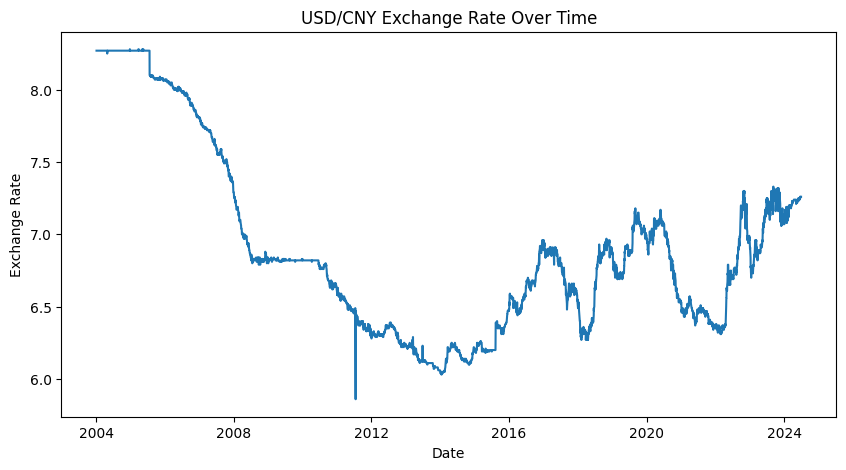

In [113]:

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title("USD/CNY Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()



## Paso 4 — Selección de variables

Se seleccionan variables relevantes del dataset.

En este caso:
- Open
- High
- Low
- Close
- CNY_pct_change


In [114]:

# data = df[['Open','High','Low','Close','CNY_pct_change']]
data = df[['Open','High','Low','Close','Adj Close','CNY_pct_change']]



## Paso 5 — Normalización

Las redes neuronales funcionan mejor cuando los datos están escalados.


In [115]:

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)



## Paso 6 — Creación de ventanas temporales

El MLP no tiene memoria del tiempo.

Por lo tanto se crean **ventanas temporales**, donde los valores de varios días anteriores se usan para predecir el siguiente.


In [131]:

X = []
y = []
# Usamos una ventana de 4 días para predecir el siguiente día
window = 4

# Creamos las secuencias de entrada (X) y las etiquetas (y)
# Para cada punto en el tiempo, tomamos los 4 días anteriores como entrada y el valor del día siguiente como etiqueta
# En este caso, queremos predecir el cambio porcentual del CNY, que está en la columna 4 (índice 4)
for i in range(len(data_scaled) - window):
    X.append(data_scaled[i:i+window])
    y.append(data_scaled[i+window][4])

X = np.array(X)
y = np.array(y)



## Paso 7 — Preparación para el MLP

Las redes MLP esperan vectores como entrada.


In [ ]:
X = X.reshape(X.shape[0], X.shape[1]*X.shape[2])
# Convertimos X a un array
print("Shape of X:", X.shape)

Shape of X: (5267, 24)



## Paso 8 — División entrenamiento y prueba
Se utiliza:

- 80% entrenamiento
- 20% prueba

En series temporales **no se mezclan los datos**.


In [118]:

train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]



## Paso 9 — Construcción del modelo MLP

Arquitectura utilizada:

Input → 64 neuronas → 32 neuronas → salida

Se usan funciones **ReLU** porque ayudan al aprendizaje no lineal.


In [119]:

model = nn.Sequential(
    nn.Linear(X_train.shape[1],64),
    nn.ReLU(),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



## Paso 10 — Entrenamiento del modelo
Se entrena el modelo durante varias épocas.


In [120]:

losses = []
epochs = 100

for epoch in range(epochs):

    inputs = torch.tensor(X_train, dtype=torch.float32)
    targets = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

    outputs = model(inputs)
    loss = criterion(outputs, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    print(f"Epoch {epoch}, Loss: {loss.item()}")


Epoch 0, Loss: 0.3509596288204193
Epoch 1, Loss: 0.3266182243824005
Epoch 2, Loss: 0.3050340414047241
Epoch 3, Loss: 0.2851264774799347
Epoch 4, Loss: 0.2655084729194641
Epoch 5, Loss: 0.24607421457767487
Epoch 6, Loss: 0.22665932774543762
Epoch 7, Loss: 0.20741787552833557
Epoch 8, Loss: 0.18779049813747406
Epoch 9, Loss: 0.16838833689689636
Epoch 10, Loss: 0.14944423735141754
Epoch 11, Loss: 0.13108263909816742
Epoch 12, Loss: 0.11344225704669952
Epoch 13, Loss: 0.09661387652158737
Epoch 14, Loss: 0.08077989518642426
Epoch 15, Loss: 0.06607721000909805
Epoch 16, Loss: 0.05276184901595116
Epoch 17, Loss: 0.041057903319597244
Epoch 18, Loss: 0.031207652762532234
Epoch 19, Loss: 0.023415513336658478
Epoch 20, Loss: 0.017896220088005066
Epoch 21, Loss: 0.01468411274254322
Epoch 22, Loss: 0.01365587580949068
Epoch 23, Loss: 0.014458820223808289
Epoch 24, Loss: 0.016617821529507637
Epoch 25, Loss: 0.019498860463500023
Epoch 26, Loss: 0.022414883598685265
Epoch 27, Loss: 0.02476195059716701


## Curva de aprendizaje
Permite observar cómo disminuye el error durante el entrenamiento.


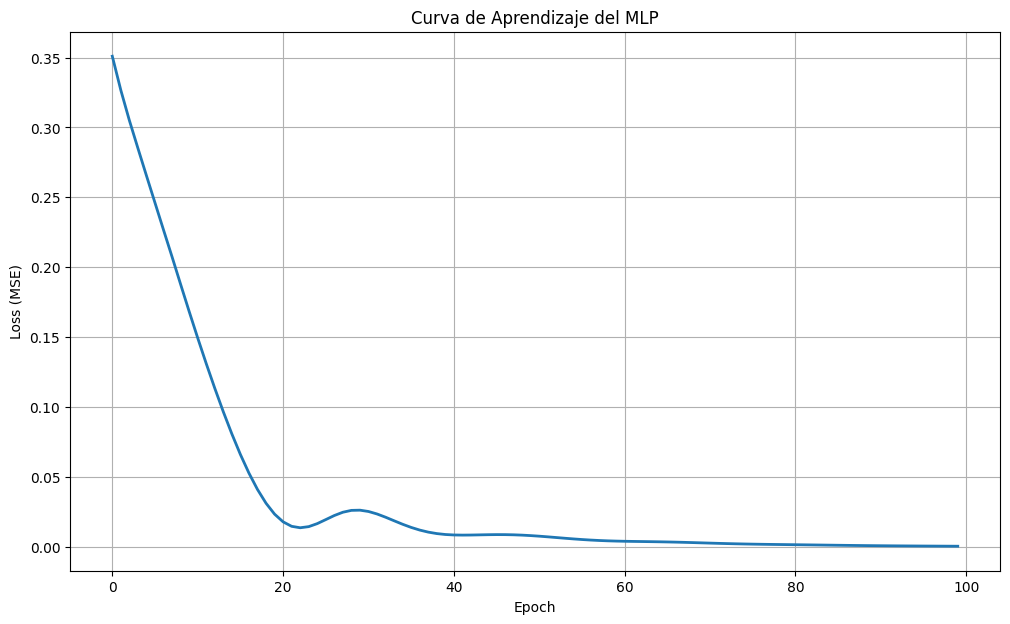

In [121]:
plt.figure(figsize=(12,7))

plt.plot(losses, linewidth=2)

plt.title("Curva de Aprendizaje del MLP")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")

plt.grid(True)

plt.show()


## Paso 11 — Predicciones
Se utiliza el conjunto de prueba para evaluar el modelo.


In [122]:

with torch.no_grad():
    test_inputs = torch.tensor(X_test, dtype=torch.float32)
    predictions = model(test_inputs)

predictions = predictions.numpy()



## Comparación: valores reales vs predicción


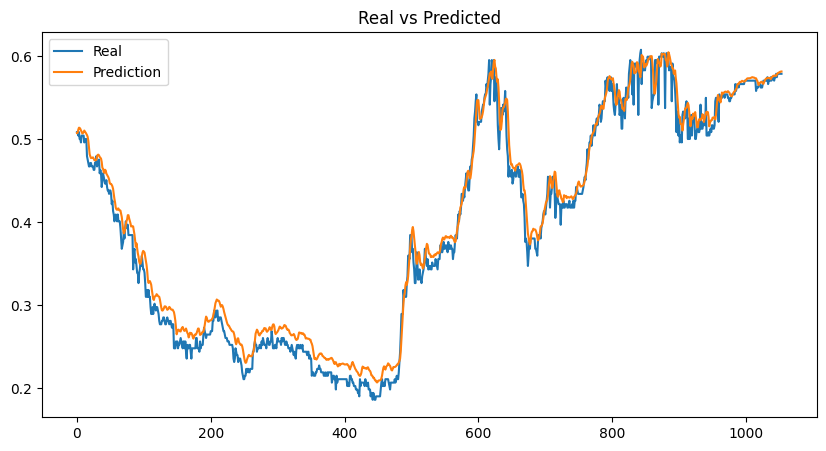

In [123]:

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Real")
plt.plot(predictions, label="Prediction")
plt.legend()
plt.title("Real vs Predicted")
plt.show()



## Evaluación del modelo
Se utilizan métricas comunes para regresión.


In [124]:

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 0.01444680731762433
RMSE: 0.017854440204883342
R2: 0.9822871572779369



## Predicción futura (Forecast)

Se puede usar el modelo para predecir el siguiente valor de la serie temporal.


In [125]:

last_window = X[-1]
last_window = torch.tensor(last_window, dtype=torch.float32)

future_pred = model(last_window)

print("Next predicted value:", future_pred.item())


Next predicted value: 0.5812849998474121
